# Klasifikacija srčanih oboljenja primenom MLP neuronskih mreža i SMOTE metode

# 1. Opis problema

Ovaj projekat predstavlja primenu višeslojne perceptronske neuronske mreže (MLP) za predikciju srčanih oboljenja na osnovu medicinskih karakteristika pacijenata. Projekat je urađen u okviru predmeta Duboko učenje i neuronske mreže.

Cilj projekta je da se na osnovu dostupnih kliničkih parametara predvidi prisustvo srčanog oboljenja. Problem je formulisan kao zadatak binarne klasifikacije, pri čemu model određuje da li pacijent pripada grupi sa prisutnim srčanim oboljenjem ili grupi bez oboljenja.

Poseban fokus projekta stavljen je na analizu uticaja balansiranja podataka primenom SMOTE metode, kao i na ispitivanje uticaja različitih hiperparametara neuronske mreže na performanse klasifikacije.

# 2. Podaci

U ovom projektu korišćen je javno dostupan Heart Disease Cleveland UCI Dataset.

Dataset sadrži medicinske podatke o pacijentima i predstavlja jedan od najčešće korišćenih skupova podataka za istraživanja iz oblasti predikcije srčanih oboljenja.

Iako dataset sadrži svega 297 uzoraka, izabran je zbog svoje široke zastupljenosti u naučnoj literaturi, medicinske relevantnosti atributa i mogućnosti poređenja rezultata sa postojećim istraživanjima.

In [62]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sb

import random
import tensorflow as tf

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [63]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [64]:
uploaded = files.upload()

Saving heart_cleveland_upload.csv to heart_cleveland_upload (2).csv


In [65]:
df = pd.read_csv("heart_cleveland_upload.csv")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


Prikaz prvih nekoliko redova omogućava uvid u strukturu skupa podataka i tipove atributa koji će biti korišćeni tokom treniranja modela.

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


Analizom strukture podataka utvrđeno je da dataset sadrži 297 instanci i 14 atributa. Sve kolone sadrže vrednosti za svaki uzorak, što ukazuje da dataset nema nedostajuće podatke.

In [67]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


Deskriptivna statistika pruža pregled raspodele numeričkih atributa i omogućava identifikaciju potencijalnih odstupanja, ekstremnih vrednosti i razlika u opsezima atributa.

In [68]:
df.duplicated().sum()

np.int64(0)

In [69]:
df.isna().sum().sum()

np.int64(0)

Analiza duplikata i nedostajućih vrednosti pokazuje da dataset ne sadrži duplikate, kao ni nedostajuće podatke, zbog čega nije bilo potrebe za dodatnim tehnikama imputacije i brisanjem dupliranih kolona.

In [70]:
df['condition'].value_counts()

,count
condition,
0,160
1,137


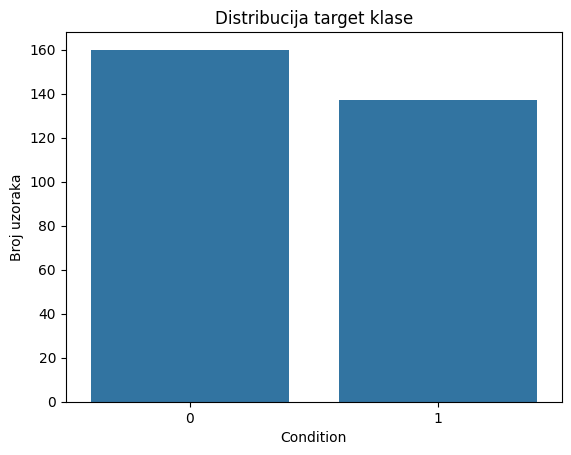

In [71]:
sb.countplot(x='condition', data=df)

plt.title("Distribucija target klase")
plt.xlabel("Condition")
plt.ylabel("Broj uzoraka")

plt.show()

Distribucija ciljnih klasa pokazuje blagu neravnotežu između pacijenata sa i bez prisutnog srčanog oboljenja. Ovakva neravnoteža može negativno uticati na proces treniranja modela, zbog čega će kasnije biti analizirana primena SMOTE metode.

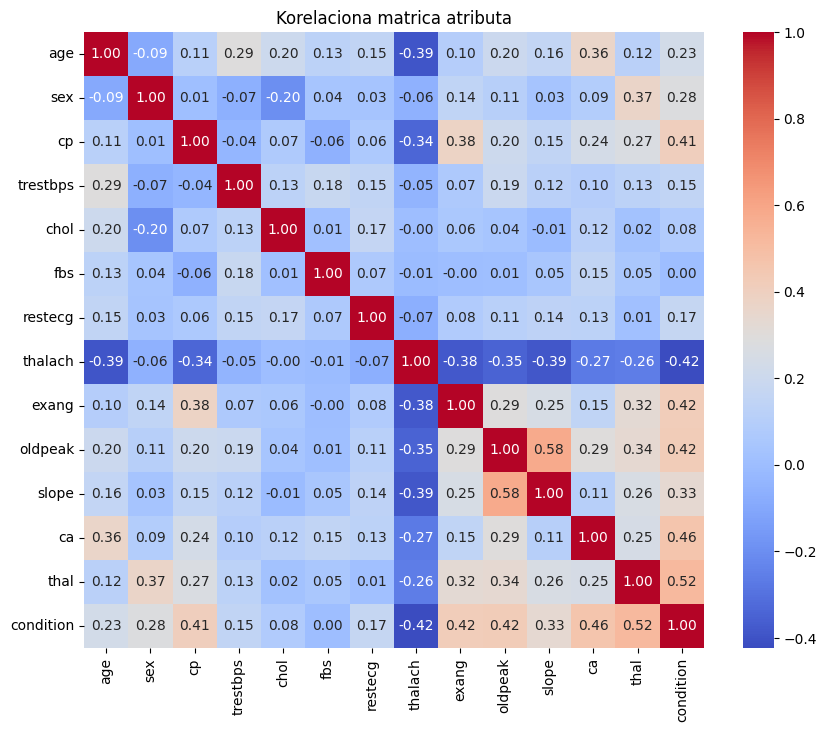

In [72]:
plt.figure(figsize=(10, 8))

sb.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title("Korelaciona matrica atributa")

plt.show()

Korelaciona matrica omogućava uvid u međusobne odnose atributa i njihovu povezanost sa ciljnom promenljivom. Pojedini atributi pokazuju izraženiju povezanost sa prisustvom srčanog oboljenja, što potvrđuje njihovu potencijalnu prediktivnu vrednost.

# 3. Preprocesiranje podataka

Za rešavanje problema korišćena je višeslojna perceptronska neuronska mreža (MLP).

Pre treniranja modela izvršena je podela podataka na trening i test skup, kao i standardizacija atributa radi stabilnijeg procesa optimizacije.

In [73]:
X = df.drop('condition', axis=1)
y = df['condition']

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [75]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [76]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (237, 13)
X_test shape: (60, 13)
y_train shape: (237,)
y_test shape: (60,)


In [77]:
X_train_scaled[:5]

array([[ 0.78837327, -1.49885801, -0.13898338, -0.10550765,  0.29565146,
        -0.40925259, -0.98123015, -2.33968827, -0.7004042 ,  0.10981851,
         0.62087132,  0.29754097,  1.20019645],
       [-0.22463889,  0.6671746 , -0.13898338, -0.10550765, -0.03440665,
         2.44347872,  1.03220314,  1.04552059, -0.7004042 , -0.89121941,
        -0.94451701,  2.34151803, -0.89904015],
       [-0.56230961, -1.49885801, -0.13898338, -0.6686904 , -0.5586166 ,
        -0.40925259, -0.98123015,  0.37738726, -0.7004042 ,  0.44349781,
         0.62087132, -0.72444757, -0.89904015],
       [-1.57532177,  0.6671746 , -1.16832908,  0.17608372, -0.86925954,
        -0.40925259, -0.98123015, -0.7807105 , -0.7004042 , -0.89121941,
         0.62087132, -0.72444757,  0.15057815],
       [ 1.46371471,  0.6671746 ,  0.89036231,  0.68294819, -1.06341137,
         2.44347872, -0.98123015, -0.37983051, -0.7004042 ,  1.94505469,
         0.62087132,  1.3195295 ,  1.20019645]])

Standardizacija atributa izvršena je korišćenjem StandardScaler metode. Ovim postupkom svi atributi dobijaju približno istu skalu, što doprinosi efikasnijem učenju neuronske mreže.

# 4. SMOTE balansiranje

U ovoj fazi primenjena je SMOTE metoda nad trening skupom podataka.

SMOTE generiše sintetičke uzorke manjinske klase kako bi se postigla balansiranija distribucija klasa tokom treniranja. Metoda se primenjuje isključivo nad trening podacima, dok test skup ostaje neizmenjen radi objektivne evaluacije modela.

In [78]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Pre SMOTE:")
print(y_train.value_counts())

print("\nPosle SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Pre SMOTE:
condition
0    128
1    109
Name: count, dtype: int64

Posle SMOTE:
condition
1    128
0    128
Name: count, dtype: int64


Primenom SMOTE metode izvršeno je balansiranje trening skupa generisanjem sintetičkih uzoraka manjinske klase.

Na ovaj način omogućeno je ravnomernije predstavljanje obe klase tokom procesa treniranja.

# 5. Arhitektura modela i pomoćne funkcije

Radi jednostavnijeg izvođenja većeg broja eksperimenata, implementirane su pomoćne funkcije za kreiranje i evaluaciju neuronskih mreža.

Korišćena je višeslojna perceptronska neuronska mreža (MLP) sa dva skrivena sloja. Funkcija za kreiranje modela omogućava jednostavnu promenu broja neurona, Dropout regularizacije i learning rate parametra, što olakšava sprovođenje hiperparametarske optimizacije.

Kao aktivaciona funkcija u skrivenim slojevima korišćen je ReLU, dok je na izlaznom sloju korišćena sigmoid funkcija zbog binarne prirode problema klasifikacije.

In [79]:
def build_mlp_model(hidden_layers=[32, 16], dropout_rate=0.2, learning_rate=0.001):
    model = Sequential()

    model.add(Dense(hidden_layers[0], activation='relu', input_shape=(13,)))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    model.add(Dense(hidden_layers[1], activation='relu'))

    if dropout_rate > 0:
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

Definisana funkcija za evaluaciju modela automatski generiše najvažnije metrike klasifikacije i konfuzionu matricu.

Na ovaj način omogućeno je dosledno poređenje različitih konfiguracija modela korišćenjem istih kriterijuma evaluacije.

In [80]:
def evaluate_experiment(model, X_test, y_test, model_name):
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    cm = confusion_matrix(y_test, y_pred)

    result = {
        "Model": model_name,
        "Accuracy": report["accuracy"],
        "Precision (1)": report["1"]["precision"],
        "Recall (1)": report["1"]["recall"],
        "F1-score (1)": report["1"]["f1-score"],
        "False Negatives": cm[1][0],
        "False Positives": cm[0][1]
    }

    return result, cm

## 6. Trening i hiperparametarska optimizacija

U cilju analize osetljivosti modela definisano je više eksperimentalnih konfiguracija koje se razlikuju po arhitekturi mreže, primeni Dropout regularizacije, vrednosti learning rate parametra i korišćenju SMOTE metode.

Svi eksperimenti izvršavaju se automatski kroz jedinstven eksperimentalni pipeline, što omogućava objektivno poređenje performansi različitih konfiguracija.

In [81]:
experiment_configs = [
    {
        "name": "Baseline_32_16_dropout02_lr001",
        "hidden_layers": [32, 16],
        "dropout_rate": 0.2,
        "learning_rate": 0.001,
        "use_smote": False
    },
    {
        "name": "SMOTE_32_16_dropout02_lr001",
        "hidden_layers": [32, 16],
        "dropout_rate": 0.2,
        "learning_rate": 0.001,
        "use_smote": True
    },
    {
        "name": "Arch_64_32_dropout02_lr001",
        "hidden_layers": [64, 32],
        "dropout_rate": 0.2,
        "learning_rate": 0.001,
        "use_smote": False
    },
    {
        "name": "NoDropout_32_16_lr001",
        "hidden_layers": [32, 16],
        "dropout_rate": 0.0,
        "learning_rate": 0.001,
        "use_smote": False
    },
    {
        "name": "LR0005_32_16_dropout02",
        "hidden_layers": [32, 16],
        "dropout_rate": 0.2,
        "learning_rate": 0.0005,
        "use_smote": False
    },
    {
        "name": "LR001_32_16_dropout02",
        "hidden_layers": [32, 16],
        "dropout_rate": 0.2,
        "learning_rate": 0.01,
        "use_smote": False
    },
    {
        "name": "Combined_64_32_dropout03_lr001",
        "hidden_layers": [64, 32],
        "dropout_rate": 0.3,
        "learning_rate": 0.001,
        "use_smote": False
    },
    {
        "name": "Combined_64_32_dropout03_lr01",
        "hidden_layers": [64, 32],
        "dropout_rate": 0.3,
        "learning_rate": 0.01,
        "use_smote": False
    }
]

In [82]:
X_train_smote.shape

(256, 13)

In [83]:
results = {}
histories = {}
confusion_matrices = {}

for config in experiment_configs:
    print("=" * 80)
    print(f"Pokreće se eksperiment: {config['name']}")

    model = build_mlp_model(
        hidden_layers=config["hidden_layers"],
        dropout_rate=config["dropout_rate"],
        learning_rate=config["learning_rate"]
    )

    if config["use_smote"]:
        X_train_exp = X_train_smote
        y_train_exp = y_train_smote
    else:
        X_train_exp = X_train_scaled
        y_train_exp = y_train

    history = model.fit(
        X_train_exp,
        y_train_exp,
        epochs=50,
        batch_size=16,
        validation_split=0.2,
        verbose=0
    )

    result, cm = evaluate_experiment(
        model,
        X_test_scaled,
        y_test,
        config["name"]
    )

    results[config["name"]] = result
    histories[config["name"]] = history.history
    confusion_matrices[config["name"]] = cm

    print(result)

Pokreće se eksperiment: Baseline_32_16_dropout02_lr001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
{'Model': 'Baseline_32_16_dropout02_lr001', 'Accuracy': 0.8833333333333333, 'Precision (1)': 1.0, 'Recall (1)': 0.75, 'F1-score (1)': 0.8571428571428571, 'False Negatives': np.int64(7), 'False Positives': np.int64(0)}
Pokreće se eksperiment: SMOTE_32_16_dropout02_lr001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
{'Model': 'SMOTE_32_16_dropout02_lr001', 'Accuracy': 0.9166666666666666, 'Precision (1)': 1.0, 'Recall (1)': 0.8214285714285714, 'F1-score (1)': 0.9019607843137255, 'False Negatives': np.int64(5), 'False Positives': np.int64(0)}
Pokreće se eksperiment: Arch_64_32_dropout02_lr001


...

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
{'Model': 'LR001_32_16_dropout02', 'Accuracy': 0.9166666666666666, 'Precision (1)': 1.0, 'Recall (1)': 0.8214285714285714, 'F1-score (1)': 0.9019607843137255, 'False Negatives': np.int64(5), 'False Positives': np.int64(0)}
Pokreće se eksperiment: Combined_64_32_dropout03_lr001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
{'Model': 'Combined_64_32_dropout03_lr001', 'Accuracy': 0.9166666666666666, 'Precision (1)': 1.0, 'Recall (1)': 0.8214285714285714, 'F1-score (1)': 0.9019607843137255, 'False Negatives': np.int64(5), 'False Positives': np.int64(0)}
Pokreće se eksperiment: Combined_64_32_dropout03_lr01


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
{'Model': 'Combined_64_32_dropout03_lr01', 'Accuracy': 0.9, 'Precision (1)': 0.9583333333333334, 'Recall (1)': 0.8214285714285714, 'F1-score (1)': 0.8846153846153846, 'False Negatives': np.int64(5), 'False Positives': np.int64(1)}


Testirane konfiguracije obuhvataju:
- baseline model,
- model treniran nad SMOTE balansiranim podacima,
- model sa većom arhitekturom 64-32,
- model bez Dropout regularizacije,
- model sa learning rate vrednošću 0.0005,
- model sa learning rate vrednošću 0.01,
- kombinovani model sa arhitekturom 64-32 i Dropout vrednošću 0.3,
- kombinovani model sa arhitekturom 64-32, Dropout vrednošću 0.3 i learning rate vrednošću 0.01.

In [84]:
results_df = pd.DataFrame(results.values())

results_df = results_df.sort_values(
    by=["F1-score (1)", "Recall (1)", "Accuracy"],
    ascending=False
)

results_df

,Model,Accuracy,Precision (1),Recall (1),F1-score (1),False Negatives,False Positives
1,SMOTE_32_16_dropout02_lr001,0.916667,1.000000,0.821429,0.901961,5,0
2,Arch_64_32_dropout02_lr001,0.916667,1.000000,0.821429,0.901961,5,0
5,LR001_32_16_dropout02,0.916667,1.000000,0.821429,0.901961,5,0
6,Combined_64_32_dropout03_lr001,0.916667,1.000000,0.821429,0.901961,5,0
7,Combined_64_32_dropout03_lr01,0.900000,0.958333,0.821429,0.884615,5,1
3,NoDropout_32_16_lr001,0.883333,0.956522,0.785714,0.862745,6,1
0,Baseline_32_16_dropout02_lr001,0.883333,1.000000,0.750000,0.857143,7,0
4,LR0005_32_16_dropout02,0.850000,1.000000,0.678571,0.808511,9,0


Rezultati eksperimenata pokazuju da više konfiguracija ostvaruje veoma slične performanse. Najbolje rezultate ostvaruju modeli koji imaju isti F1-score i recall vrednost, dok dodatni kombinovani model sa većim learning rate parametrom ne donosi dodatno poboljšanje.

Ovaj rezultat ukazuje da pojedinačno dobri hiperparametri ne moraju nužno da daju bolji rezultat kada se kombinuju u istom modelu.

In [85]:
best_model_name = results_df.iloc[0]["Model"]
best_model_name

'SMOTE_32_16_dropout02_lr001'

Na osnovu ostvarenih rezultata kao najbolji model odabran je model treniran nad SMOTE balansiranim podacima.

Ovaj model ostvario je najbolji balans između tačnosti klasifikacije i sposobnosti prepoznavanja pacijenata sa prisutnim srčanim oboljenjem.

# 7. Rezultati evaluacije

Za detaljnu analizu performansi najboljeg modela korišćeni su classification report i konfuziona matrica.

Posebna pažnja posvećena je recall metrici zbog njenog značaja u medicinskim problemima klasifikacije.

In [86]:
best_model = build_mlp_model(
    hidden_layers=[32, 16],
    dropout_rate=0.2,
    learning_rate=0.001
)

best_model.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [87]:
y_pred_prob_best = best_model.predict(X_test_scaled)

y_pred_best = (
    y_pred_prob_best > 0.5
).astype(int)

print(
    classification_report(
        y_test,
        y_pred_best
    )
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
              precision    recall  f1-score   support

           0       0.84      1.00      0.91        32
           1       1.00      0.79      0.88        28

    accuracy                           0.90        60
   macro avg       0.92      0.89      0.90        60
weighted avg       0.92      0.90      0.90        60



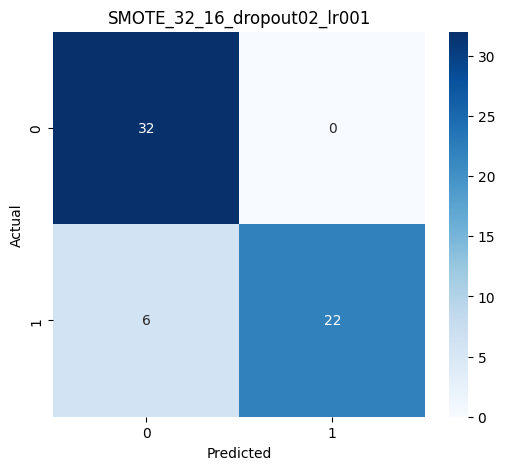

In [88]:
cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,5))

sb.heatmap(
    cm_best,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(best_model_name)

plt.show()

Konfuziona matrica pokazuje da model ostvaruje visok broj tačno klasifikovanih slučajeva uz mali broj grešaka.

Posebno je značajno što je broj lažno negativnih predikcija relativno nizak, budući da takve greške predstavljaju najveći rizik u medicinskim primenama.

# 8. Diskusija

Dobijeni rezultati pokazuju da povećanje složenosti modela ne mora nužno dovesti do poboljšanja performansi.

Eksperimenti sa različitim arhitekturama i hiperparametrima pokazali su da jednostavniji modeli mogu biti podjednako efikasni kao i složenije konfiguracije, naročito kada se radi o manjim skupovima podataka.

Dodatni kombinovani eksperiment pokazao je da kombinovanje većeg broja neurona, jače Dropout regularizacije i većeg learning rate parametra nije dovelo do poboljšanja u odnosu na prethodno najbolje modele.

Takođe, rezultati ukazuju da kvalitetna priprema podataka i balansiranje klasa mogu imati veći uticaj na performanse modela od samog povećanja broja neurona ili slojeva.

Iako je više konfiguracija ostvarilo veoma slične rezultate, model sa SMOTE balansiranjem izabran je kao finalni jer direktno odgovara cilju projekta i ostvaruje najbolje vrednosti ključnih metrika.

# 9. Zaključak

U okviru projekta razvijen je sistem za klasifikaciju srčanih oboljenja primenom višeslojne perceptronske neuronske mreže.

Analiziran je uticaj različitih hiperparametara i SMOTE metode za balansiranje podataka. Najbolje rezultate ostvario je model treniran nad SMOTE balansiranim podacima, koji je postigao približno 91.7% tačnosti i F1-score od 0.90.

Rezultati potvrđuju da neuronske mreže mogu uspešno rešavati probleme medicinske klasifikacije i da balansiranje podataka predstavlja važan korak u izgradnji pouzdanih modela.

Kao budući pravci razvoja izdvajaju se primena većih skupova podataka, k-fold validacija, ensemble metode i integracija modela u inteligentni sistem za procenu rizika od srčanih oboljenja.

# Čuvanje najboljeg modela

Najbolji model se čuva u `.keras` formatu kako bi mogao da se koristi u budućim projektima bez potrebe za ponovnim treniranjem.

In [89]:
best_model = build_mlp_model(
    hidden_layers=[32, 16],
    dropout_rate=0.2,
    learning_rate=0.001
)

best_model.fit(
    X_train_smote,
    y_train_smote,
    epochs=50,
    batch_size=16,
    validation_split=0.2,
    verbose=0
)

best_model.save("heart_disease_mlp_smote.keras")

print("Model sačuvan.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model sačuvan.
